## Simple MLP

In [41]:
import torch
from torch import nn # nn -> 딥러닝 아키텍쳐 구현을 위한 여러 함수들이 구현되어있는 집합
import warnings
warnings.filterwarnings('ignore')


In [4]:
x = torch.tensor([1.])
model = nn.Linear(1, 1) # 입력 node 한 개, 출력 node 한 개인 layer 만듦

print(model.weight) # 만들면서 initialize한다.
print(model.bias)

Parameter containing:
tensor([[0.4842]], requires_grad=True)
Parameter containing:
tensor([-0.5466], requires_grad=True)


In [6]:
y = model(x)
print(y)

y = x @ model.weight + model.bias
print(y)

tensor([-0.0625], grad_fn=<ViewBackward0>)
tensor([-0.0625], grad_fn=<AddBackward0>)


In [ ]:
fc1 = nn.Linear(1, 3) # fully-connected
fc2 = nn.Linear(3, 1)

print(fc1.weight)
print(fc1.bias)
print(fc2.weight)
print(fc2.bias) # bias 갯수 1개!

Parameter containing:
tensor([[-0.5452],
        [ 0.2966],
        [-0.5218]], requires_grad=True)
Parameter containing:
tensor([ 0.9297,  0.4027, -0.4882], requires_grad=True)
Parameter containing:
tensor([[-0.1409, -0.3506,  0.2797]], requires_grad=True)
Parameter containing:
tensor([0.0993], requires_grad=True)


In [ ]:
x=torch.tensor([1.])
x=fc1(x)
print(x)
x=fc2(x)
print(x)

tensor([ 0.3845,  0.6993, -1.0100], grad_fn=<ViewBackward0>)
tensor([-0.4826], grad_fn=<ViewBackward0>)


In [10]:
x=torch.tensor([1.])
y = (x@fc1.weight.T+fc1.bias)@fc2.weight.T+fc2.bias
print(y)

tensor([-0.4826], grad_fn=<AddBackward0>)


In [ ]:
# nn.Linear 는 개수x채x행x열에서 "채" 형태로 (1D data) 들어오길 기대하는 녀석이다.
# 1D data를 다룰때는 행x열은 신경쓰지말고 개x채에 집중
# 채는 약간 하나의 데이터 열의 수를 말하고, 개는 데이터의 행의 수 즉 데이터의 갯수를 말한다.
# 따라서, 데이터 여러개를 통과시키고 싶다면 개x채 의 형태로 줘야 함


# why T? weight도 개x채 형태로 만들기 위함!
# 일단, weight shape 개x채에서 채는 무조건 앞에 거 채널 개수와 맞추셈!
# 예를 들어, nn.Linear(2,3) 이면 앞에거 채널 개수는 2 따라서 ?x2 인데
# 두 채널 값을 가지고 3개의 노드를 만드는 거라서 3x2 가 된다!

In [13]:
print(y)
# input size: 1
# fc1.weight.T size: 1x3
# fc1.bias size: 3
# fc2.weight.T size: 3x1
# fc2.bias size: 1

tensor([-0.4826], grad_fn=<AddBackward0>)


In [14]:
print("-"*15, "기존", "-"*15)
fc1 = nn.Linear(1, 3)
fc2 = nn.Linear(3, 1)
x = torch.tensor([1.])
x = fc1(x)
x = fc2(x)

print(x)

print("-"*15, "use Sequential", "-"*15)
model = nn.Sequential(fc1, fc2) # layer 풀칠
x = torch.tensor([1.])
print(model(x))

--------------- 기존 ---------------
tensor([1.0865], grad_fn=<ViewBackward0>)
--------------- use Sequential ---------------
tensor([1.0865], grad_fn=<ViewBackward0>)


In [ ]:
model = nn.Sequential(nn.Linear(2, 5), # 여기는 채, 채 --> 채 == feature
                      nn.Linear(5, 10),
                      nn.Linear(10, 3))

x = torch.randn(2) 
print(x)
print(model(x))

tensor([ 0.8797, -0.0833])
tensor([-0.0037, -0.1267,  0.2096], grad_fn=<ViewBackward0>)


In [17]:
x = torch.randn(1, 2)
print(x)
print(model(x))

tensor([[ 0.4784, -0.5581]])
tensor([[-0.0775, -0.0988,  0.2857]], grad_fn=<AddmmBackward0>)


In [19]:
x = torch.randn(5, 2) # 개 x 채 --> 두 개의 채널(feature)(키, 몸무게)를 가지는 데이터(사람) 5개를 통과시킴
print(x)
print(model(x))

tensor([[ 0.6348, -0.8506],
        [-0.5164, -0.4577],
        [-0.4251,  0.8398],
        [-0.1105,  0.4716],
        [ 0.0312,  1.1236]])
tensor([[-0.0898, -0.0436,  0.2771],
        [-0.1504, -0.2065,  0.4179],
        [-0.0313, -0.3775,  0.3481],
        [-0.0372, -0.2969,  0.3211],
        [ 0.0306, -0.3737,  0.2728]], grad_fn=<AddmmBackward0>)


In [ ]:
x=torch.randn(2,3,1,4,5,2) # -> 개개개개개개개 X 채
print(model(x).shape)

```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self, x):
```

In [20]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(2,5)
        self.fc2 = nn.Linear(5,10)
        self.fc3 = nn.Linear(10,3)
        self.sig1 = nn.Sigmoid()
        self.sig2 = nn.Sigmoid()
        self.sig3 = nn.Sigmoid()
        
    def forward(self, x): # x => 우리가 집어넣을 데이터
        x = self.fc1(x)
        x = self.sig1(x)
        x = self.fc2(x)
        x = self.sig2(x)
        x = self.fc3(x)
        x = self.sig3(x)
        return x
    
    
model = MyModel()
x = torch.randn(5,2)
print(x)
y = model(x)
print(y)    

tensor([[ 1.5173,  1.6137],
        [ 1.2609, -0.8023],
        [-0.0608,  0.3305],
        [ 1.2899, -2.7364],
        [ 1.2364, -1.3032]])
tensor([[0.4163, 0.3990, 0.4893],
        [0.4171, 0.3992, 0.4900],
        [0.4181, 0.4041, 0.4953],
        [0.4177, 0.3991, 0.4902],
        [0.4173, 0.3993, 0.4901]], grad_fn=<SigmoidBackward0>)


```python
# nn.Module의 __call__ 내부 (단순화)
def __call__(self, x):
    # forward() 만 자동 호출!
    return self.forward(x)



class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 5)
    
    def forward(self, x):
        print("forward 실행!")  # 자동 실행
        return self.fc1(x)
    
    def my_func(self):
        print("my_func 실행!")  # 자동 실행 안됨!!

model = MyModel()
model(x)
# "forward 실행!"  ← 출력됨
# "my_func 실행!" ← 출력 안됨!!
```

In [22]:
print(model)
print(model.fc1.weight)
print(model.fc2.bias)

MyModel(
  (fc1): Linear(in_features=2, out_features=5, bias=True)
  (fc2): Linear(in_features=5, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=3, bias=True)
  (sig1): Sigmoid()
  (sig2): Sigmoid()
  (sig3): Sigmoid()
)
Parameter containing:
tensor([[-0.7045, -0.0767],
        [-0.5239,  0.2805],
        [ 0.6429,  0.3547],
        [ 0.4212, -0.1797],
        [-0.6727, -0.5325]], requires_grad=True)
Parameter containing:
tensor([ 0.0599, -0.2401,  0.2097, -0.4016,  0.1176,  0.3111, -0.1104, -0.2051,
         0.1172, -0.0152], requires_grad=True)


In [23]:
class MyModel2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential( #linear --> 내가 원하는 이름으로 명명 가능하노
            nn.Linear(2, 5),
            nn.Sigmoid(),
            nn.Linear(5, 10),
            nn.Sigmoid(),
            nn.Linear(10, 3),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.linear(x)
        return(x)



model2 = MyModel2()
x = torch.randn(5, 2)
y = model2(x)
print(y)


tensor([[0.5739, 0.5050, 0.6090],
        [0.5721, 0.5012, 0.6086],
        [0.5737, 0.5022, 0.6068],
        [0.5749, 0.5032, 0.6056],
        [0.5740, 0.5059, 0.6097]], grad_fn=<SigmoidBackward0>)


In [ ]:
model2 = MyModel2()
x = torch.randn(5, 2, requires_grad=True)
y = model2(x)

# back-prop : Loss function을 따로 설명 안했으니깐 그냥 sum한 value(vector -> scalar)로 backward 진행
y.sum().backward()
print(x)
print(x.grad)
# gradient = d loss / d parameter -> 스칼라

tensor([[-0.5540, -2.0348],
        [-0.6711, -0.5311],
        [-0.0932, -1.0214],
        [ 1.1449, -0.4092],
        [-0.5446,  1.0659]], requires_grad=True)
tensor([[-1.6112e-03, -2.9315e-04],
        [-1.7142e-03, -1.1440e-04],
        [-1.7423e-03, -1.7024e-04],
        [-1.5711e-03,  3.5038e-05],
        [-1.6734e-03, -2.0360e-04]])


In [32]:
print(model2)
print("-"*15, "weight", "-"*15)
print(model2.linear[0].weight)
print("-"*15, "bias", "-"*15)
print(model2.linear[-2].bias)

MyModel2(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=5, out_features=10, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=10, out_features=3, bias=True)
    (5): Sigmoid()
  )
)
--------------- weight ---------------
Parameter containing:
tensor([[ 0.4864,  0.4206],
        [ 0.1582,  0.6164],
        [ 0.2117,  0.1966],
        [-0.1187,  0.6001],
        [-0.1874,  0.2004]], requires_grad=True)
--------------- bias ---------------
Parameter containing:
tensor([0.1172, 0.0437, 0.2048], requires_grad=True)


In [31]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.7045, -0.0767],
         [-0.5239,  0.2805],
         [ 0.6429,  0.3547],
         [ 0.4212, -0.1797],
         [-0.6727, -0.5325]], requires_grad=True),
 Parameter containing:
 tensor([-0.6808, -0.4990,  0.5344, -0.6543, -0.6231], requires_grad=True),
 Parameter containing:
 tensor([[-0.1432, -0.0305,  0.3109, -0.3525,  0.3290],
         [ 0.3404, -0.1494, -0.1504, -0.2799,  0.1256],
         [-0.0478,  0.4067, -0.3662, -0.2841, -0.1631],
         [ 0.0291, -0.4076,  0.3965,  0.0657, -0.1016],
         [ 0.2890,  0.1814, -0.2564,  0.4062,  0.1844],
         [ 0.2979, -0.1966, -0.3078,  0.0936, -0.0461],
         [ 0.2756, -0.1071, -0.0198, -0.1196, -0.0810],
         [-0.0964, -0.0583,  0.1908,  0.2815,  0.3392],
         [ 0.0755, -0.0466,  0.3178,  0.3864, -0.1102],
         [-0.0879,  0.0859,  0.1826, -0.2274,  0.4402]], requires_grad=True),
 Parameter containing:
 tensor([ 0.0599, -0.2401,  0.2097, -0.4016,  0.1176,  0.3111, -0.1104, -0.2051,
  

In [33]:
# # of parameters
num = sum([p.numel() for p in model.parameters() if p.requires_grad])
print(num)

108


In [37]:
num_par = 0
for p in model.parameters():
    if p.requires_grad:
        num_par = p.numel() + num_par
        
print(num_par)

108


## Checking gradient vanishing

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

층 번호 | gradient 평균 크기
----------------------------------------
1층 (layers.0.weight): 0.0000000004
2층 (layers.2.weight): 0.0000000019
3층 (layers.4.weight): 0.0000000131
4층 (layers.6.weight): 0.0000000774
5층 (layers.8.weight): 0.0000006027
6층 (layers.10.weight): 0.0000052707
7층 (layers.12.weight): 0.0000353069
8층 (layers.14.weight): 0.0002457710
9층 (layers.16.weight): 0.0019512147
10층 (layers.18.weight): 0.0907433629


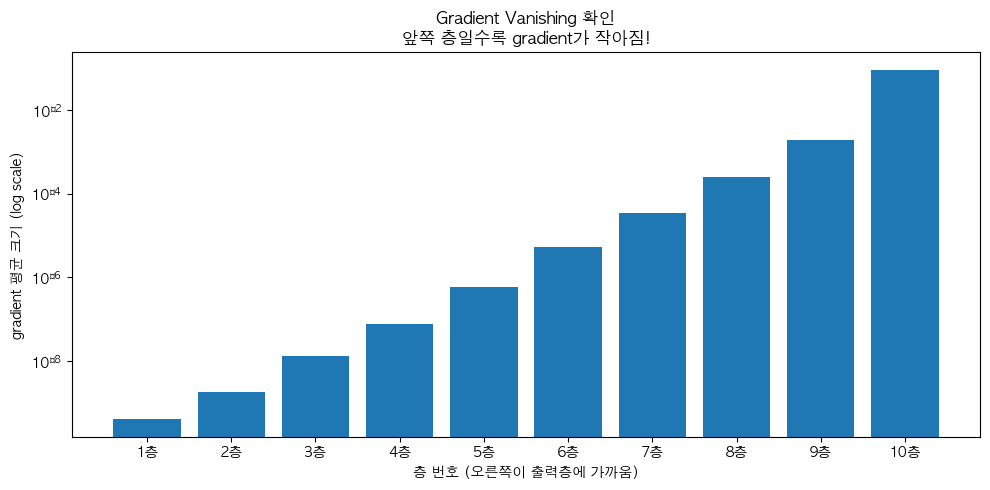

In [42]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

x = torch.randn(5, 2)
y = torch.randn(5, 1)

class VanishingModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 32),  nn.Sigmoid(),
            nn.Linear(32, 32), nn.Sigmoid(),
            nn.Linear(32, 32), nn.Sigmoid(),
            nn.Linear(32, 32), nn.Sigmoid(),
            nn.Linear(32, 32), nn.Sigmoid(),
            nn.Linear(32, 32), nn.Sigmoid(),
            nn.Linear(32, 32), nn.Sigmoid(),
            nn.Linear(32, 32), nn.Sigmoid(),
            nn.Linear(32, 32), nn.Sigmoid(),
            nn.Linear(32, 1),  nn.Sigmoid(),  # 10층
        )
    
    def forward(self, x):
        return self.layers(x)

model = VanishingModel()

# Forward + Loss + Backward
loss_fn = nn.MSELoss()
y_hat = model(x)
loss = loss_fn(y_hat, y)
loss.backward()

# 각 층의 gradient 크기 출력
print("층 번호 | gradient 평균 크기")
print("-" * 40)

layer_num = 1
grad_values = []
layer_names = []

for name, param in model.named_parameters():
    if 'weight' in name:  # weight만 확인 (bias 제외)
        grad_mean = param.grad.abs().mean().item()
        print(f"{layer_num}층 ({name}): {grad_mean:.10f}")
        grad_values.append(grad_mean)
        layer_names.append(f"{layer_num}층")
        layer_num += 1

plt.figure(figsize=(10, 5))
plt.bar(layer_names, grad_values)
plt.yscale('log')  
plt.xlabel("층 번호 (오른쪽이 출력층에 가까움)")
plt.ylabel("gradient 평균 크기 (log scale)")
plt.title("Gradient Vanishing 확인\n앞쪽 층일수록 gradient가 작아짐!")
plt.tight_layout()
plt.show()